# Unit 4: Model Evaluation

## Evaluation Metrics

- **Accuracy**: Overall correctness of the model  
- **Confusion Matrix**: Shows TP, TN, FP, FN  
- **Precision**: TP / (TP + FP)  
- **Recall**: TP / (TP + FN)  
- **F1-Score**: Harmonic mean of Precision & Recall  
- **ROC Curve**: Graph between TPR and FPR  
- **AUC**: Area under ROC curve  

### Error Analysis
- False Positives: Predicted disease but actually healthy  
- False Negatives: Predicted healthy but actually disease (important in medical cases)


Accuracy: 0.7235714285714285
Confusion Matrix:
 [[5362 1626]
 [2244 4768]]
Precision: 0.7456990928995934
Recall: 0.6799771819737592
F1 Score: 0.7113232880799641


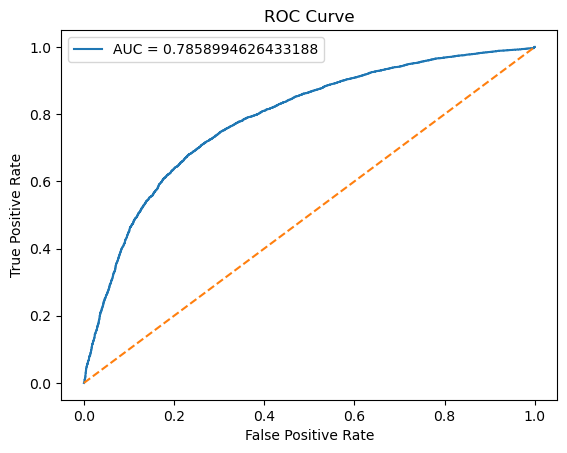

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)

# Load dataset
df = pd.read_csv("cardio.csv")

# Preprocessing
df = df.drop_duplicates()
df = df.drop('id', axis=1)
df['age'] = df['age'] / 365
df = df.fillna(df.mean(numeric_only=True))

# Split
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
